# Benchmark SpMM INT8: SAURIA densa vs SAURIA + Gather

Questo notebook unisce:

- il flusso GEMM INT8 dell'esempio SAURIA;
- il benchmark SAURIA vs SAURIA + Gather già usato per FP16;
- la configurazione hardware `int8_8x16_AXI64`.

L'operazione confrontata è:

```text
W_int8[M,K] @ X_int8[K,N] = C_int32[M,N]
```

Nel baseline SAURIA, `W[M,K]` contiene zeri espliciti. Nel percorso
SAURIA + Gather, le stesse colonne non nulle vengono salvate in CSR/CSC,
la matrice dei valori diventa `W_compact[M,k_eff]` e il Gather costruisce
`X_compact[k_eff,N]` direttamente nella SRAM A.

Il golden è verificato in tre modi:

1. `numpy.matmul` con cast degli operandi a `int32`, come nell'esempio INT8;
2. modello numerico ufficiale SAURIA;
3. confronto finale della DRAM prodotto da Verilator.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from math import ceil, log2
from pathlib import Path
from typing import Iterable, Sequence
import json
import re
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "RTL").is_dir()
            and (candidate / "Python").is_dir()
            and (candidate / "test").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Repository SAURIA non trovata")


REPO_ROOT = find_repo_root(Path.cwd())
PYTHON_DIR = REPO_ROOT / "Python"
NOTEBOOK_DIR = PYTHON_DIR / "notebooks"
TEST_DIR = REPO_ROOT / "test"
VERILATOR_DIR = TEST_DIR / "verilator"
RUNTIME_STIMULI_DIR = TEST_DIR / "stimuli"
RESULTS_ROOT = TEST_DIR / "spmm_gather_vs_dense_int8_8x16_axi64"

for path in (PYTHON_DIR, PYTHON_DIR / "src", NOTEBOOK_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

try:
    import dotenv
    for env_path in (PYTHON_DIR / "env", REPO_ROOT / "env", REPO_ROOT / ".env"):
        if env_path.exists():
            dotenv.load_dotenv(env_path)
            break
except ImportError:
    pass

import src.hw_versions as hwv
import src.sauria_lib as slib
import src.config_helper as cfg
import src.data_helper as dh
import src.file_helper as fh
import src.execution_model as ex

print("REPO_ROOT:", REPO_ROOT)
print("VERILATOR_DIR:", VERILATOR_DIR)
print("RESULTS_ROOT:", RESULTS_ROOT)


REPO_ROOT: /home/henry/sauria
VERILATOR_DIR: /home/henry/sauria/test/verilator
RESULTS_ROOT: /home/henry/sauria/test/spmm_gather_vs_dense_int8_8x16_axi64


## 1. Configurazione INT8

La versione hardware attesa è `int8_8x16_AXI64`:

- array SAURIA: `X=16`, `Y=8`;
- input A: INT8;
- pesi B: INT8;
- output/partial sum C: INT32;
- bus dati esterno: AXI64;
- Gather: 8 elementi INT8 per beat.

Per il primo test è consigliato `K=64`.

In [2]:
SAURIA_VERSION = "int8_8x16_AXI64"

# Output tile handled by the 16x8 systolic array.
M = 16
N = 8

# Reduction dimension.
# Recommended:
#   64   -> smoke test
#   128  -> normal benchmark
#   256  -> large benchmark
#   512  -> very large benchmark
#   1024 -> maximum Gather dense capacity for N=8 and INT8
K = 64

SPARSE_FORMAT = "CSR"

ACTIVE_FRACTIONS = [0.90, 0.70, 0.50, 0.30, 0.10]
K_EFF_POINTS = sorted(
    {
        max(1, min(K, int(round(K * fraction))))
        for fraction in ACTIVE_FRACTIONS
    },
    reverse=True,
)

SEED = 2026
COMPILE_RTL = True
RUN_SWEEP = True
SIM_DEBUG = True
CHECK_READ_VALUES = True
MAX_CYCLES = 2_000_000
REQUIRE_TESTED_RTL = True

GENERATE_WAVEFORMS = True
WAVEFORM_K_EFF = {64}
WAVEFORM_LABELS = {"gather_plus_sauria"}
WAVEFORM_START_TIME = 900

IDX_BITS = 32
IDX_BYTES = IDX_BITS // 8
IDX_PADDING_BEATS = 1

GATHER_NUM_WORDS = 128
GATHER_NUM_WORDS_IDX = 64

HW_PARAMS = hwv.get_params(SAURIA_VERSION)

AXI_BITS = int(HW_PARAMS["DATA_AXI_DATA_WIDTH"])
AXI_BYTES = AXI_BITS // 8
INPUT_BITS = int(HW_PARAMS["IA_W"])
WEIGHT_BITS = int(HW_PARAMS["IB_W"])
OUTPUT_BITS = int(HW_PARAMS["OC_W"])
INPUT_BYTES = INPUT_BITS // 8
WEIGHT_BYTES = WEIGHT_BITS // 8
OUTPUT_BYTES = OUTPUT_BITS // 8
INPUTS_PER_BEAT = AXI_BYTES // INPUT_BYTES
IDX_PER_BEAT = AXI_BYTES // IDX_BYTES

INPUT_DTYPE = np.int8
WEIGHT_DTYPE = np.int8
OUTPUT_DTYPE = np.int32
MODEL_DTYPE = np.int64

N_BLOCKS = int(HW_PARAMS["Y"])

SPARSE_FORMAT = SPARSE_FORMAT.upper()
if SPARSE_FORMAT not in {"CSR", "CSC"}:
    raise ValueError("SPARSE_FORMAT deve essere CSR oppure CSC")

assert int(HW_PARAMS["OP_TYPE"]) == 0, "La versione deve essere intera"
assert AXI_BITS == 64, "Il Gather integrato usa AXI64"
assert INPUT_BITS == 8 and WEIGHT_BITS == 8 and OUTPUT_BITS == 32
assert M == int(HW_PARAMS["X"])
assert N == int(HW_PARAMS["Y"])
assert N == N_BLOCKS
assert AXI_BYTES % INPUT_BYTES == 0
assert INPUTS_PER_BEAT & (INPUTS_PER_BEAT - 1) == 0

GATHER_DENSE_CAPACITY_ELEMENTS = (
    N_BLOCKS * GATHER_NUM_WORDS * INPUTS_PER_BEAT
)
GATHER_MAX_K = GATHER_DENSE_CAPACITY_ELEMENTS // N

# In hw_versions.py MEM*_size is already expressed as number of elements.
SAURIA_A_TILE_CAPACITY_ELEMENTS = int(HW_PARAMS["MEMA_size"])
SAURIA_B_TILE_CAPACITY_ELEMENTS = int(HW_PARAMS["MEMB_size"])
SAURIA_C_TILE_CAPACITY_ELEMENTS = int(HW_PARAMS["MEMC_size"])

assert K * N <= GATHER_DENSE_CAPACITY_ELEMENTS, (
    f"K*N={K*N} supera la capacità Gather "
    f"{GATHER_DENSE_CAPACITY_ELEMENTS} elementi INT8"
)
assert K <= GATHER_NUM_WORDS * INPUTS_PER_BEAT
assert K <= GATHER_MAX_K
assert K * N <= SAURIA_A_TILE_CAPACITY_ELEMENTS
assert M * K <= SAURIA_B_TILE_CAPACITY_ELEMENTS
assert M * N <= SAURIA_C_TILE_CAPACITY_ELEMENTS
assert all(1 <= int(k_eff) <= K for k_eff in K_EFF_POINTS)

# 127*127*K must remain within signed INT32.
MAX_ABS_ACC = 127 * 127 * K
assert MAX_ABS_ACC <= np.iinfo(np.int32).max

print("Versione:", SAURIA_VERSION)
print("Formato:", SPARSE_FORMAT)
print("M, K, N:", (M, K, N))
print("A/B/C bits:", (INPUT_BITS, WEIGHT_BITS, OUTPUT_BITS))
print("AXI bits:", AXI_BITS)
print("Elementi INT8 per beat:", INPUTS_PER_BEAT)
print("N_BLOCKS:", N_BLOCKS)
print("Gather capacity:", GATHER_DENSE_CAPACITY_ELEMENTS, "elementi INT8")
print("Gather maximum K:", GATHER_MAX_K)
print(
    "SAURIA A/B/C capacities:",
    SAURIA_A_TILE_CAPACITY_ELEMENTS,
    SAURIA_B_TILE_CAPACITY_ELEMENTS,
    SAURIA_C_TILE_CAPACITY_ELEMENTS,
    "elementi",
)
print("K_eff points:", K_EFF_POINTS)
print("Sparsità:", [1.0 - k_eff / K for k_eff in K_EFF_POINTS])

Versione: int8_8x16_AXI64
Formato: CSR
M, K, N: (16, 1024, 8)
A/B/C bits: (8, 8, 32)
AXI bits: 64
Elementi INT8 per beat: 8
N_BLOCKS: 8
Gather capacity: 8192 elementi INT8
Gather maximum K: 1024
SAURIA A/B/C capacities: 16384 32768 8192 elementi
K_eff points: [922, 717, 512, 307, 102]
Sparsità: [0.099609375, 0.2998046875, 0.5, 0.7001953125, 0.900390625]


### Waveform e multi-burst

Con INT8 ogni beat AXI64 contiene 8 valori densi, mentre gli indici restano
word da 32 bit. Per `k_eff=64` lo stream degli indici contiene
`N × k_eff = 512` indici, cioè 256 beat AXI64, più il beat di padding.
La correzione multi-burst del reader deve quindi essere presente.

### Limiti dimensionali del singolo start

Con `N_BLOCKS=8`, `NumWords=128`, AXI64 e INT8:

```text
8 blocchi × 128 beat/blocco × 8 INT8/beat = 8192 elementi
```

Per `N=8`, il limite teorico del singolo start è `K=1024`.
Il notebook controlla anche le capacità delle SRAM A, B e C di SAURIA.

## 2. Controllo RTL e compilazione

Il preflight blocca il benchmark se mancano il bit 26 o lo stato `PREPARE_B`,
oppure se `skip_initial_A` forza ancora erroneamente `keep_A=1`.


In [3]:
def git_output(*args: str) -> str:
    result = subprocess.run(
        ["git", *args],
        cwd=REPO_ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    return result.stdout.strip()


print("Branch:", git_output("branch", "--show-current"))
print("Commit:", git_output("rev-parse", "--short", "HEAD"))

if REQUIRE_TESTED_RTL:
    interface_path = REPO_ROOT / "RTL/src/df_controller/sauria_interface.sv"
    dma_path = REPO_ROOT / "RTL/src/df_controller/sauria_dma_controller.sv"
    subsystem_path = REPO_ROOT / "RTL/src/sauria_subsystem.sv"
    hw_versions_path = REPO_ROOT / "Python/src/hw_versions.py"
    svh_path = REPO_ROOT / f"RTL/hw_versions/{SAURIA_VERSION}.svh"

    reader_candidates = [
        REPO_ROOT / "RTL/src/Gather/axi4_master_read.sv",
        REPO_ROOT / "RTL/src/gather/axi4_master_read.sv",
        REPO_ROOT / "RTL/src/axi4_master_read.sv",
    ]
    reader_path = next(
        (path for path in reader_candidates if path.exists()),
        None,
    )
    if reader_path is None:
        raise FileNotFoundError(
            "axi4_master_read.sv non trovato nei percorsi attesi"
        )

    interface_text = interface_path.read_text()
    dma_text = dma_path.read_text()
    subsystem_text = subsystem_path.read_text()
    hw_versions_text = hw_versions_path.read_text()
    reader_text = reader_path.read_text()

    missing = []

    required = {
        interface_path.name: [
            "skip_initial_A_dma",
            "control_regs[21][26]",
            ".skip_initial_A(skip_initial_A_dma)",
        ],
        dma_path.name: [
            "input skip_initial_A",
            "PREPARE_B",
        ],
    }
    for filename, markers in required.items():
        text = interface_text if filename == interface_path.name else dma_text
        missing.extend(
            f"{filename}: {marker}"
            for marker in markers
            if marker not in text
        )

    if not svh_path.exists():
        missing.append(str(svh_path.relative_to(REPO_ROOT)))

    if not re.search(
        r"version\s*==\s*['\"]int8_8x16_AXI64['\"]",
        hw_versions_text,
    ):
        missing.append("hw_versions.py: int8_8x16_AXI64")

    if not re.search(
        r"\.ByteWidth\s*\(\s*sauria_pkg::IA_W\s*\)",
        subsystem_text,
    ):
        missing.append(
            "sauria_subsystem.sv: Gather ByteWidth deve usare sauria_pkg::IA_W"
        )

    forbidden = [
        marker
        for marker in (
            "skip_initial__dma",
            "(skip_initial_A_dma ? 1'b1 : keep_A)",
        )
        if marker in interface_text
    ]

    obsolete_multiburst = "32'(ar_len_out+8'd1)"
    if obsolete_multiburst in reader_text:
        forbidden.append(
            f"{reader_path.name}: overflow ARLEN nel calcolo add_addr_out"
        )

    required_reader_marker = "32'(ar_len_out) + 32'd1"
    if required_reader_marker not in reader_text:
        missing.append(
            f"{reader_path.name}: correzione multi-burst 256 beat"
        )

    if missing or forbidden:
        raise RuntimeError(
            "RTL/configurazione non validati.\n"
            f"Mancanti: {missing}\n"
            f"Obsoleti: {forbidden}"
        )

    print("RTL preflight: OK")
    print("AXI reader:", reader_path)
    print("Hardware file:", svh_path)

if COMPILE_RTL:
    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    compile_log = RESULTS_ROOT / "verilator_compile.log"
    with compile_log.open("w") as stream:
        rc = subprocess.call(
            ["sh", "./compile_sauria.sh", SAURIA_VERSION],
            cwd=VERILATOR_DIR,
            stdout=stream,
            stderr=subprocess.STDOUT,
        )
    if rc != 0:
        raise RuntimeError(f"Compilazione fallita: {compile_log}")
    print("Compilazione completata:", compile_log)

Branch: sauria-gather-benchmark
Commit: 78b3920
RTL preflight: OK
AXI reader: /home/henry/sauria/RTL/src/Gather/axi4_master_read.sv
Hardware file: /home/henry/sauria/RTL/hw_versions/int8_8x16_AXI64.svh
Compilazione completata: /home/henry/sauria/test/spmm_gather_vs_dense_int8_8x16_axi64/verilator_compile.log


## 3. Matrice sparsa INT8 in CSR/CSC

Come nell'esempio SAURIA INT8, gli operandi vengono generati direttamente
come `np.int8`. Prima del prodotto vengono promossi a `int32`, così non
avviene overflow a 8 bit durante l'accumulazione.

La sparsità è strutturata per colonne: tutte le righe di W condividono la
stessa maschera. In questo modo il percorso compresso può usare un solo
lancio SAURIA con dimensione `k_eff`.

In [4]:
@dataclass(frozen=True)
class SparseCase:
    M: int
    K: int
    N: int
    k_eff: int
    sparsity: float
    active_columns: np.ndarray
    X_full: np.ndarray
    W_dense: np.ndarray
    X_compact: np.ndarray
    W_compact: np.ndarray
    csr_row_ptr: np.ndarray
    csr_col_idx: np.ndarray
    csr_values: np.ndarray
    csc_col_ptr: np.ndarray
    csc_row_idx: np.ndarray
    csc_values: np.ndarray


def make_nested_masks(K: int, points: Sequence[int], seed: int) -> dict[int, np.ndarray]:
    points = sorted({int(value) for value in points})
    if not points or points[0] <= 0 or points[-1] > K:
        raise ValueError("k_eff fuori intervallo")
    permutation = np.random.default_rng(seed).permutation(K)
    return {
        k_eff: np.sort(permutation[:k_eff]).astype(np.uint32)
        for k_eff in points
    }


def dense_to_csr(W: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    W = np.asarray(W, dtype=WEIGHT_DTYPE)
    row_ptr = [0]
    col_idx = []
    values = []
    for row in range(W.shape[0]):
        columns = np.flatnonzero(W[row] != 0)
        col_idx.extend(int(column) for column in columns)
        values.extend(W[row, columns].tolist())
        row_ptr.append(len(col_idx))
    return (
        np.asarray(row_ptr, dtype=np.uint32),
        np.asarray(col_idx, dtype=np.uint32),
        np.asarray(values, dtype=WEIGHT_DTYPE),
    )


def dense_to_csc(W: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    W = np.asarray(W, dtype=WEIGHT_DTYPE)
    col_ptr = [0]
    row_idx = []
    values = []
    for column in range(W.shape[1]):
        rows = np.flatnonzero(W[:, column] != 0)
        row_idx.extend(int(row) for row in rows)
        values.extend(W[rows, column].tolist())
        col_ptr.append(len(row_idx))
    return (
        np.asarray(col_ptr, dtype=np.uint32),
        np.asarray(row_idx, dtype=np.uint32),
        np.asarray(values, dtype=WEIGHT_DTYPE),
    )


def active_columns_from_format(case: SparseCase, sparse_format: str) -> np.ndarray:
    if sparse_format == "CSR":
        begin = int(case.csr_row_ptr[0])
        end = int(case.csr_row_ptr[1])
        active = case.csr_col_idx[begin:end]
        for row in range(case.M):
            b = int(case.csr_row_ptr[row])
            e = int(case.csr_row_ptr[row + 1])
            if not np.array_equal(case.csr_col_idx[b:e], active):
                raise ValueError("CSR non strutturato per colonne condivise")
        return active.copy()

    counts = np.diff(case.csc_col_ptr.astype(np.int64))
    active = np.flatnonzero(counts > 0).astype(np.uint32)
    if np.any(counts[active] != case.M):
        raise ValueError("CSC con colonne solo parzialmente popolate")
    return active


def make_sparse_case(k_eff: int, active_columns: Sequence[int]) -> SparseCase:
    active = np.asarray(active_columns, dtype=np.uint32)
    if active.size != k_eff or np.any(active >= K):
        raise ValueError("Maschera non valida")

    W_dense = np.zeros((M, K), dtype=WEIGHT_DTYPE)
    W_dense[:, active] = W_MASTER[:, active]

    X_full = X_MASTER.copy()
    X_compact = np.ascontiguousarray(X_full[active, :], dtype=INPUT_DTYPE)
    W_compact = np.ascontiguousarray(W_dense[:, active], dtype=WEIGHT_DTYPE)

    csr_row_ptr, csr_col_idx, csr_values = dense_to_csr(W_dense)
    csc_col_ptr, csc_row_idx, csc_values = dense_to_csc(W_dense)

    case = SparseCase(
        M=M, K=K, N=N, k_eff=k_eff, sparsity=1.0-k_eff/K,
        active_columns=active,
        X_full=X_full, W_dense=W_dense,
        X_compact=X_compact, W_compact=W_compact,
        csr_row_ptr=csr_row_ptr, csr_col_idx=csr_col_idx, csr_values=csr_values,
        csc_col_ptr=csc_col_ptr, csc_row_idx=csc_row_idx, csc_values=csc_values,
    )

    recovered = active_columns_from_format(case, SPARSE_FORMAT)
    if not np.array_equal(recovered, active):
        raise AssertionError("Metadati sparsi incoerenti")
    return case


def save_sparse_case(case: SparseCase, directory: Path) -> None:
    directory.mkdir(parents=True, exist_ok=True)
    np.savez(
        directory / "operands_and_sparse_formats.npz",
        X_full=case.X_full,
        W_dense=case.W_dense,
        X_compact=case.X_compact,
        W_compact=case.W_compact,
        active_columns=case.active_columns,
        csr_row_ptr=case.csr_row_ptr,
        csr_col_idx=case.csr_col_idx,
        csr_values=case.csr_values,
        csc_col_ptr=case.csc_col_ptr,
        csc_row_idx=case.csc_row_idx,
        csc_values=case.csc_values,
    )
    manifest = {
        "M": M, "K": K, "N": N,
        "k_eff": case.k_eff,
        "sparsity": case.sparsity,
        "nnz": int(case.csr_values.size),
        "selected_format": SPARSE_FORMAT,
        "active_columns": case.active_columns.tolist(),
        "csr_bytes": int(
            case.csr_row_ptr.nbytes + case.csr_col_idx.nbytes + case.csr_values.nbytes
        ),
        "csc_bytes": int(
            case.csc_col_ptr.nbytes + case.csc_row_idx.nbytes + case.csc_values.nbytes
        ),
    }
    (directory / "sparse_case_manifest.json").write_text(
        json.dumps(manifest, indent=2) + "\n"
    )


rng = np.random.default_rng(SEED)

# Same principle as the official INT8 example: generate operands directly
# as signed 8-bit integers. Zero weights are replaced only in W_MASTER so
# that active columns have an exactly shared sparsity pattern.
X_MASTER = rng.integers(
    low=-127,
    high=128,
    size=(K, N),
    dtype=INPUT_DTYPE,
)
W_MASTER = rng.integers(
    low=-127,
    high=128,
    size=(M, K),
    dtype=WEIGHT_DTYPE,
)
W_MASTER[W_MASTER == 0] = WEIGHT_DTYPE(1)

MASKS = make_nested_masks(K, K_EFF_POINTS, SEED + 1)
display(pd.DataFrame([
    {
        "k_eff": k_eff,
        "sparsity": 1-k_eff/K,
        "active_columns": MASKS[k_eff].tolist(),
    }
    for k_eff in sorted(MASKS, reverse=True)
]))


,k_eff,sparsity,active_columns
0,922,0.099609,"[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14..."
1,717,0.299805,"[1, 3, 4, 5, 8, 10, 11, 12, 13, 14, 15, 17, 18..."
2,512,0.500000,"[1, 3, 4, 5, 8, 10, 11, 12, 13, 14, 15, 17, 20..."
3,307,0.700195,"[3, 5, 10, 11, 12, 14, 15, 20, 21, 26, 30, 31,..."
4,102,0.900391,"[5, 11, 12, 30, 35, 40, 49, 71, 74, 75, 81, 91..."


## 4. Golden INT32 e stimuli vanilla SAURIA

L'esempio ufficiale INT8 calcola la GEMM promuovendo A e B a `int32`.
Qui il risultato NumPy viene confrontato con il modello numerico SAURIA.
Solo dopo questa verifica vengono generati gli stimuli.

In [5]:
def make_conv_dict(A: np.ndarray, B: np.ndarray, C: np.ndarray, k_channels: int) -> dict:
    tiling = {
        "C_tile_shape": [M, 1, N],
        "tile_cin": int(k_channels),
        "X_used": M,
        "Y_used": N,
    }
    return slib.get_conv_dict(
        [A.shape, B.shape, C.shape],
        tiling,
        HW_PARAMS,
        d=1,
        s=1,
        preloads=False,
    )


def numpy_int8_gemm(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Official-example style golden: INT8 operands, INT32 accumulation."""
    A_matrix = np.asarray(A, dtype=INPUT_DTYPE).reshape(A.shape[0], N)
    B_matrix = np.asarray(B, dtype=WEIGHT_DTYPE).reshape(M, A.shape[0])
    C_matrix = np.matmul(
        B_matrix.astype(np.int32),
        A_matrix.astype(np.int32),
    )
    return C_matrix.reshape(M, 1, N).astype(OUTPUT_DTYPE)


def hardware_golden(
    A: np.ndarray,
    B: np.ndarray,
    C: np.ndarray,
    conv_dict: dict,
) -> np.ndarray:
    result, _, _ = ex.get_ideal_results(
        A,
        B,
        C,
        conv_dict,
        HW_PARAMS,
        slib.get_sa_dict(HW_PARAMS),
        compute_macs=False,
    )
    return np.asarray(result, dtype=MODEL_DTYPE)


def assert_int_golden_equal(
    label: str,
    model_result: np.ndarray,
    numpy_result: np.ndarray,
) -> None:
    model_i64 = np.asarray(model_result, dtype=np.int64)
    numpy_i64 = np.asarray(numpy_result, dtype=np.int64)
    if not np.array_equal(model_i64, numpy_i64):
        diff = model_i64 - numpy_i64
        index = tuple(int(v) for v in np.argwhere(diff != 0)[0])
        raise AssertionError(
            f"{label}: modello SAURIA e NumPy non coincidono. "
            f"Primo mismatch {index}: model={model_i64[index]}, "
            f"numpy={numpy_i64[index]}"
        )


def generate_sauria_stimuli(
    *,
    A: np.ndarray,
    B: np.ndarray,
    C_preload: np.ndarray,
    C_golden: np.ndarray,
    conv_dict: dict,
    test_root: Path,
) -> dict:
    if test_root.exists():
        shutil.rmtree(test_root)
    test_root.mkdir(parents=True)

    B_opt = dh.optimize_weight_tensor_shape(B, conv_dict)
    dram, dram_gold, offsets = dh.assign_dram_values(
        A, B_opt, C_preload, C_golden, 0, conv_dict, HW_PARAMS
    )
    sauria_regs, n_regs = cfg.get_sauria_regs(conv_dict, HW_PARAMS, silent=True)
    _, _, _, loop_order = ex.get_tiling_loops(conv_dict)
    controller_args = cfg.get_controller_regs(
        conv_dict, sauria_regs, n_regs, offsets, loop_order
    )
    fh.generate_test_files(
        dram,
        dram_gold,
        controller_args,
        [offsets[0], offsets[2], offsets[3]],
        HW_PARAMS,
        n_regs,
        test_dir=str(test_root),
    )
    return {
        "stimuli_dir": test_root / "stimuli",
        "offsets": offsets,
        "n_regs": n_regs,
    }

## 5. Patch degli stimuli Gather → SRAM A

La sequenza validata resta invariata:

```text
Gather legge X densa e metadati dalla DRAM
Gather scrive X_compact nella SRAM A
controller SAURIA usa skip_initial_A
DMA carica B e C
core INT8×INT8 accumula in INT32
DMA scrive C nella DRAM
```

La sorgente DRAM della A compatta viene avvelenata: se il DMA A non viene
davvero saltato, il confronto finale fallisce.

In [6]:
GATHER_BASE = 0x7000_0000
SAURIA_BASE = 0x5000_0000
SRAMA_LOCAL = 0x0004_0000
SRAMA_DEBUG = SAURIA_BASE + SRAMA_LOCAL

REG_START = 0x00
REG_IS_SPMM = 0x04
REG_DONE = 0x08
REG_AR_SIZE = 0x0C
REG_AW_SIZE = 0x10
REG_AR_ADDR_DENSE_MATRIX = 0x14
REG_TOTAL_LEN_DENSE_MATRIX = 0x18
REG_AR_ADDR_COMP_IDX = 0x1C
REG_TOTAL_LEN_COMP_IDX = 0x20
REG_AR_ADDR_IDX = 0x24
REG_TOTAL_LEN_IDX = 0x28
REG_AXI_WR_AW_ADDR_IN = 0x2C
REG_STATUS_REG_N_ROW = 0x30

CTRL_START_ADDR = 0x4000_0000
CTRL_FLAGS_ADDR = 0x4000_0064
CTRL_STANDALONE_BIT = 18
CTRL_KEEP_A_BIT = 19
CTRL_KEEP_B_BIT = 20
CTRL_KEEP_C_BIT = 21
CTRL_SKIP_INITIAL_A_BIT = 26

VARIABLE_CORE_READS = {0x5000_0014, 0x5000_0018}
STIMULI_FILES = ("GoldenStimuli.txt", "initial_dram.txt", "gold_dram.txt", "tstcfg.txt")


def gaddr(offset: int) -> int:
    return GATHER_BASE + offset


def nbeats(nbytes: int) -> int:
    return ceil(int(nbytes) / AXI_BYTES)


def align_up(value: int, alignment: int = 0x1000) -> int:
    return (int(value) + alignment - 1) & ~(alignment - 1)


def find_file(directory: Path, filename: str) -> Path:
    path = Path(directory) / filename
    if path.exists():
        return path
    matches = sorted(Path(directory).glob(filename.replace(".txt", "*.txt")))
    if matches:
        return matches[0]
    raise FileNotFoundError(path)


def read_stimuli(path: Path) -> list[list[int]]:
    rows = []
    for lineno, line in enumerate(path.read_text().splitlines(), start=1):
        if not line.strip():
            continue
        row = [int(token, 16) for token in line.split()]
        if len(row) != 7:
            raise ValueError(f"{path}:{lineno}: riga non valida")
        rows.append(row)
    return rows


def write_stimuli(path: Path, rows: Sequence[Sequence[int]]) -> None:
    with path.open("w") as stream:
        for row in rows:
            stream.write(" ".join(f"{int(v) & 0xFFFFFFFF:X}" for v in row) + "\n")


def read_byte_memory(path: Path) -> list[int]:
    return [int(line, 16) & 0xFF for line in path.read_text().splitlines() if line.strip()]


def write_byte_memory(path: Path, memory: Sequence[int]) -> None:
    with path.open("w") as stream:
        for value in memory:
            stream.write(f"{int(value) & 0xFF:X}\n")


def ensure_len(memory: list[int], size: int) -> None:
    if len(memory) < size:
        memory.extend([0] * (size - len(memory)))


def write_bytes(memory: list[int], address: int, data: Iterable[int]) -> None:
    payload = [int(value) & 0xFF for value in data]
    ensure_len(memory, address + len(payload))
    memory[address:address+len(payload)] = payload


def zero_range(memory: list[int], address: int, nbytes: int) -> None:
    write_bytes(memory, address, [0] * nbytes)


def write_le(memory: list[int], address: int, value: int, nbytes: int) -> None:
    write_bytes(
        memory,
        address,
        ((int(value) >> (8 * byte)) & 0xFF for byte in range(nbytes)),
    )


def read_input_region(path: Path, address: int, elements: int) -> np.ndarray:
    memory = read_byte_memory(path)
    end = address + elements * INPUT_BYTES
    if end > len(memory):
        raise ValueError(f"Regione A fuori da {path}")
    return np.frombuffer(bytes(memory[address:end]), dtype=np.int8).copy()


def input_bytes(array: np.ndarray) -> bytes:
    return np.asarray(array, dtype=np.int8).reshape(-1).tobytes(order="C")


def stim_write(address: int, data: int) -> list[int]:
    return [data & 0xFFFFFFFF, address & 0xFFFFFFFF, 1, 0, 0, 0, 0]


def stim_read(address: int, expected: int = 0) -> list[int]:
    return [0, address & 0xFFFFFFFF, 0, 1, 0, expected & 0xFFFFFFFF, 0]


def stim_wait_gather() -> list[int]:
    return [0, 0, 0, 0, 2, 0, 0]


def u32_le(data: bytes) -> int:
    return int.from_bytes(data[:4].ljust(4, b"\0"), "little")


def remove_variable_reads(rows: list[list[int]]) -> list[list[int]]:
    return [
        row for row in rows
        if not (row[1] in VARIABLE_CORE_READS and row[2] == 0 and row[3] == 1)
    ]


def patch_flags(rows: list[list[int]], skip_initial_a: bool) -> tuple[int, int]:
    matches = [row for row in rows if row[2] == 1 and row[1] == CTRL_FLAGS_ADDR]
    if len(matches) != 1:
        raise RuntimeError(f"Scritture flags trovate: {len(matches)}")
    row = matches[0]
    old = int(row[0])
    new = old
    for bit in (CTRL_STANDALONE_BIT, CTRL_KEEP_A_BIT, CTRL_KEEP_B_BIT, CTRL_KEEP_C_BIT):
        new &= ~(1 << bit)
    if skip_initial_a:
        new |= 1 << CTRL_SKIP_INITIAL_A_BIT
    else:
        new &= ~(1 << CTRL_SKIP_INITIAL_A_BIT)
    row[0] = new & 0xFFFFFFFF
    return old, new


def start_positions(rows: Sequence[Sequence[int]]) -> list[int]:
    return [
        i for i, row in enumerate(rows)
        if row[2] == 1 and row[1] == CTRL_START_ADDR and row[0] == 3
    ]


def start_index(rows: Sequence[Sequence[int]]) -> int:
    positions = start_positions(rows)
    if len(positions) != 1:
        raise RuntimeError(f"Start SAURIA trovati: {positions}")
    return positions[0]


def pack_spmm_column_index(column: int) -> int:
    if not 0 <= column < GATHER_NUM_WORDS * INPUTS_PER_BEAT:
        raise ValueError("Colonna Gather fuori intervallo")
    lane_bits = int(log2(INPUTS_PER_BEAT))
    return ((column // INPUTS_PER_BEAT) << lane_bits) | (column % INPUTS_PER_BEAT)


def build_hw_layout(
    full_a_hw: np.ndarray,
    compact_a_hw: np.ndarray,
    active_columns: Sequence[int],
) -> dict:
    """
    Costruisce il layout fisico usato dal Gather spMM.

    La A originale è salvata da SAURIA in ordine C come:
        X[K, N].flatten()

    Il Gather dispone di N_BLOCKS blocchi SRAM. Il flusso lineare originale
    viene quindi diviso in N_BLOCKS segmenti consecutivi. In modalità spMM
    cnt_stage_out seleziona il blocco, mentre l'indice compresso seleziona
    una posizione locale nel blocco.

    Per ottenere X_compact[k_eff, N].flatten(), ogni colonna K attiva
    contribuisce con i suoi N valori consecutivi. Gli indici devono quindi
    essere distribuiti nel blocco fisico che contiene tali valori, non
    ripetuti identici in ogni blocco.
    """
    active = np.asarray(active_columns, dtype=np.uint32)
    if active.ndim != 1 or active.size == 0:
        raise ValueError("active_columns deve essere un vettore non vuoto")
    if np.any(active >= K):
        raise ValueError("Colonna attiva fuori intervallo")
    if np.any(active[1:] <= active[:-1]):
        raise ValueError(
            "active_columns deve essere strettamente crescente; "
            "l'ordine definisce la K compatta"
        )

    total_elements = K * N
    if total_elements % N_BLOCKS != 0:
        raise ValueError(
            f"K*N={total_elements} non divisibile per N_BLOCKS={N_BLOCKS}"
        )

    elements_per_block = total_elements // N_BLOCKS

    full_flat = np.ascontiguousarray(
        np.asarray(full_a_hw, dtype=np.int8).reshape(-1)
    )
    compact_expected = np.ascontiguousarray(
        np.asarray(compact_a_hw, dtype=np.int8).reshape(-1)
    )

    if full_flat.size != total_elements:
        raise ValueError(
            f"A full contiene {full_flat.size} elementi, attesi {total_elements}"
        )

    expected_compact_elements = int(active.size) * N
    if compact_expected.size != expected_compact_elements:
        raise ValueError(
            f"A compact contiene {compact_expected.size} elementi, "
            f"attesi {expected_compact_elements}"
        )

    # Mantiene esattamente l'ordine lineare prodotto da assign_dram_values.
    physical_dense = np.ascontiguousarray(
        full_flat.reshape(N_BLOCKS, elements_per_block)
    )

    # Posizioni globali nel flatten X[K,N] richieste dalla matrice compatta.
    selected_global_positions = np.concatenate(
        [
            np.arange(
                int(column) * N,
                (int(column) + 1) * N,
                dtype=np.int64,
            )
            for column in active
        ]
    )

    comp_ptr_values = [0]
    packed_indices: list[int] = []
    gathered_values: list[np.int8] = []
    block_nnz: list[int] = []
    block_local_indices: list[list[int]] = []

    for block in range(N_BLOCKS):
        block_start = block * elements_per_block
        block_end = block_start + elements_per_block

        in_block = selected_global_positions[
            (selected_global_positions >= block_start)
            & (selected_global_positions < block_end)
        ]
        local_indices = (in_block - block_start).astype(np.int64)

        block_local_indices.append(
            [int(value) for value in local_indices]
        )
        block_nnz.append(int(local_indices.size))

        for local_index in local_indices:
            packed_indices.append(
                pack_spmm_column_index(int(local_index))
            )
            gathered_values.append(
                physical_dense[block, int(local_index)]
            )

        comp_ptr_values.append(len(packed_indices))

    gathered_output = np.ascontiguousarray(
        np.asarray(gathered_values, dtype=np.int8)
    )

    if gathered_output.size != compact_expected.size:
        raise AssertionError(
            f"Gather output size={gathered_output.size}, "
            f"compact size={compact_expected.size}"
        )

    if not np.array_equal(
        gathered_output.view(np.uint8),
        compact_expected.view(np.uint8),
    ):
        mismatch = np.flatnonzero(
            gathered_output.view(np.uint8)
            != compact_expected.view(np.uint8)
        )
        index = int(mismatch[0])
        raise AssertionError(
            "Il mapping a blocchi non ricostruisce la A compatta: "
            f"primo mismatch all'elemento {index}, "
            f"gather=0x{int(gathered_output.view(np.uint8)[index]):02X}, "
            f"compact=0x{int(compact_expected.view(np.uint8)[index]):02X}"
        )

    # Il CU usa uno zero finale come sentinella dopo l'ultimo puntatore.
    comp_ptr = np.asarray(
        [*comp_ptr_values, 0],
        dtype=np.uint32,
    )
    packed_idx = np.asarray(packed_indices, dtype=np.uint32)

    # NumWords_idx limits the compressed pointer SRAM only.
    # The column-index stream is consumed through AXI -> FIFO -> PISO and may
    # contain far more than 256 entries. total_len_idx and the multi-burst
    # reader carry the complete stream.
    pointer_capacity = GATHER_NUM_WORDS_IDX * IDX_PER_BEAT
    if comp_ptr.size > pointer_capacity:
        raise ValueError(
            f"Pointer SRAM overflow: {comp_ptr.size} entries, "
            f"capacity {pointer_capacity}"
        )

    return {
        "physical_dense": physical_dense,
        "selected_dense": gathered_output,
        "comp_ptr": comp_ptr,
        "packed_idx": packed_idx,
        "status_reg_n_row": elements_per_block - 1,
        "elements_per_block": elements_per_block,
        "block_nnz": block_nnz,
        "block_local_indices": block_local_indices,
        "pointer_entries": int(comp_ptr.size),
        "index_entries": int(packed_idx.size),
        "index_natural_beats": nbeats(packed_idx.nbytes),
    }


def patch_dense_stimuli(in_dir: Path, out_dir: Path) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    rows = remove_variable_reads(read_stimuli(find_file(in_dir, "GoldenStimuli.txt")))
    old, new = patch_flags(rows, skip_initial_a=False)
    if len(start_positions(rows)) != 1:
        raise AssertionError("Baseline con numero start non valido")
    write_stimuli(out_dir / "GoldenStimuli.txt", rows)
    for name in STIMULI_FILES[1:]:
        shutil.copy2(find_file(in_dir, name), out_dir / name)
    manifest = {
        "mode": "dense_sauria",
        "flags_old": f"0x{old:08X}",
        "flags_new": f"0x{new:08X}",
        "controller_starts": start_positions(rows),
    }
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest


def patch_gather_stimuli(
    *,
    in_dir: Path,
    out_dir: Path,
    full_a_hw: np.ndarray,
    compact_a_hw: np.ndarray,
    active_columns: Sequence[int],
    compact_a_dram_base: int,
    debug_words: int = 4,
    poison_byte: int = 0xA5,
) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    layout = build_hw_layout(full_a_hw, compact_a_hw, active_columns)

    rows = remove_variable_reads(read_stimuli(find_file(in_dir, "GoldenStimuli.txt")))
    old, new = patch_flags(rows, skip_initial_a=True)
    initial = read_byte_memory(find_file(in_dir, "initial_dram.txt"))
    golden = read_byte_memory(find_file(in_dir, "gold_dram.txt"))

    dense_payload = input_bytes(layout["physical_dense"])
    selected_payload = input_bytes(layout["selected_dense"])
    high_water = max(len(initial), len(golden))
    dense_base = align_up(high_water + 0x1000)
    comp_beats = nbeats(layout["comp_ptr"].nbytes)
    comp_base = align_up(dense_base + len(dense_payload))
    idx_natural_beats = nbeats(layout["packed_idx"].nbytes)
    idx_total_beats = idx_natural_beats + IDX_PADDING_BEATS
    idx_base = align_up(comp_base + comp_beats * AXI_BYTES)

    for memory in (initial, golden):
        write_bytes(memory, dense_base, dense_payload)

        zero_range(memory, comp_base, comp_beats * AXI_BYTES)
        for i, value in enumerate(layout["comp_ptr"]):
            write_le(memory, comp_base + i * IDX_BYTES, int(value), IDX_BYTES)

        zero_range(memory, idx_base, idx_total_beats * AXI_BYTES)
        for i, value in enumerate(layout["packed_idx"]):
            write_le(memory, idx_base + i * IDX_BYTES, int(value), IDX_BYTES)

        write_bytes(
            memory,
            compact_a_dram_base,
            [poison_byte] * len(selected_payload),
        )

    gather_rows = [
        stim_write(gaddr(REG_AR_SIZE), 3),
        stim_write(gaddr(REG_AW_SIZE), 3),
        stim_write(gaddr(REG_AR_ADDR_DENSE_MATRIX), dense_base),
        stim_write(gaddr(REG_TOTAL_LEN_DENSE_MATRIX), nbeats(len(dense_payload))),
        stim_write(gaddr(REG_AR_ADDR_COMP_IDX), comp_base),
        stim_write(gaddr(REG_TOTAL_LEN_COMP_IDX), comp_beats),
        stim_write(gaddr(REG_AR_ADDR_IDX), idx_base),
        stim_write(gaddr(REG_TOTAL_LEN_IDX), idx_total_beats),
        stim_write(gaddr(REG_AXI_WR_AW_ADDR_IN), SRAMA_LOCAL),
        stim_write(gaddr(REG_STATUS_REG_N_ROW), layout["status_reg_n_row"]),
        stim_write(gaddr(REG_IS_SPMM), 1),
        stim_write(gaddr(REG_START), 1),
        stim_wait_gather(),
        stim_read(gaddr(REG_DONE), 1),
    ]
    debug_expected = {}
    for word in range(debug_words):
        offset = word * 4
        expected = u32_le(selected_payload[offset:offset+4])
        address = SRAMA_DEBUG + offset
        debug_expected[address] = expected
        gather_rows.append(stim_read(address, expected))

    insertion = start_index(rows)
    rows = rows[:insertion] + gather_rows + rows[insertion:]
    if len(start_positions(rows)) != 1:
        raise AssertionError("Percorso Gather con più start SAURIA")

    write_stimuli(out_dir / "GoldenStimuli.txt", rows)
    write_byte_memory(out_dir / "initial_dram.txt", initial)
    write_byte_memory(out_dir / "gold_dram.txt", golden)
    shutil.copy2(find_file(in_dir, "tstcfg.txt"), out_dir / "tstcfg.txt")

    manifest = {
        "mode": "gather_then_single_sauria_skip_initial_A",
        "sparse_format": SPARSE_FORMAT,
        "active_columns": [int(v) for v in active_columns],
        "physical_A_shape": list(layout["physical_dense"].shape),
        "compact_A_shape": [len(active_columns), N],
        "gather_output_flat_shape": list(layout["selected_dense"].shape),
        "elements_per_block": layout["elements_per_block"],
        "block_nnz": layout["block_nnz"],
        "block_local_indices": layout["block_local_indices"],
        "pointer_entries": layout["pointer_entries"],
        "index_entries": layout["index_entries"],
        "index_natural_beats_from_layout": layout["index_natural_beats"],
        "is_spmm": 1,
        "dense_base": f"0x{dense_base:08X}",
        "comp_base": f"0x{comp_base:08X}",
        "idx_base": f"0x{idx_base:08X}",
        "dense_beats": nbeats(len(dense_payload)),
        "comp_beats": comp_beats,
        "idx_natural_beats": idx_natural_beats,
        "idx_padding_beats": IDX_PADDING_BEATS,
        "idx_total_beats": idx_total_beats,
        "flags_old": f"0x{old:08X}",
        "flags_new": f"0x{new:08X}",
        "skip_initial_A": bool((new >> CTRL_SKIP_INITIAL_A_BIT) & 1),
        "standalone_keep_A": bool((new >> CTRL_KEEP_A_BIT) & 1),
        "controller_starts": start_positions(rows),
        "poison_compact_A": True,
        "debug_expected": {
            f"0x{address:08X}": f"0x{value:08X}"
            for address, value in debug_expected.items()
        },
    }
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest


## 6. Simulazione, waveform e parser robusto

Il benchmark è considerato valido solo quando compare esattamente:

```text
Benchmark passed with no errors.
```

Il parser misura separatamente il Gather, la SAURIA compressa e il tempo
end-to-end.

In [7]:
def sync_runtime_stimuli(source_dir: Path) -> Path:
    RUNTIME_STIMULI_DIR.mkdir(parents=True, exist_ok=True)
    for filename in STIMULI_FILES:
        shutil.copy2(find_file(source_dir, filename), RUNTIME_STIMULI_DIR / filename)
    for stale in RUNTIME_STIMULI_DIR.glob("*.json"):
        stale.unlink()
    for source in Path(source_dir).glob("*.json"):
        shutil.copy2(source, RUNTIME_STIMULI_DIR / source.name)
    return RUNTIME_STIMULI_DIR.resolve()


def parse_log(log_text: str) -> dict:
    passed = "Benchmark passed with no errors." in log_text
    failed = "Benchmark failed" in log_text
    benchmark_match = re.search(r"\[(\d+)\]\s+Benchmark\s+(passed|failed)", log_text)

    status = "pass" if passed else ("fail" if failed else "timeout")
    last_tick = None
    gather_start = gather_done = sauria_start = sauria_done = None
    debug_reads = {}

    for line in log_text.splitlines():
        match = re.search(r"\[(\d+)\]", line)
        if match:
            last_tick = int(match.group(1))

        if "Writing 1 into address 70000000" in line and gather_start is None:
            gather_start = last_tick
        elif "Gather done." in line and gather_done is None:
            gather_done = last_tick
        elif "Writing 3 into address 40000000" in line and sauria_start is None:
            sauria_start = last_tick
        elif "New test" in line and sauria_done is None:
            sauria_done = last_tick

        read_match = re.search(
            r"Read\s+([0-9A-Fa-f]+)\s+from address\s+([0-9A-Fa-f]+)",
            line,
        )
        if read_match:
            value = int(read_match.group(1), 16)
            address = int(read_match.group(2), 16)
            if SRAMA_DEBUG <= address < SRAMA_DEBUG + 0x100:
                debug_reads[address] = value

    def cycles(start, end):
        if start is None or end is None or end < start:
            return None
        return (end - start) / 10.0

    flow_start = gather_start if gather_start is not None else sauria_start
    return {
        "status": status,
        "timeout": benchmark_match is None,
        "clean_pass": passed,
        "last_tick": last_tick,
        "gather_cycles": cycles(gather_start, gather_done),
        "sauria_cycles": cycles(sauria_start, sauria_done),
        "flow_cycles": cycles(flow_start, sauria_done),
        "debug_reads": debug_reads,
    }


def run_testsim(
    stimuli_dir: Path,
    output_dir: Path,
    label: str,
    *,
    enable_waveform: bool = False,
):
    runtime_dir = sync_runtime_stimuli(stimuli_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    command = [
        "./Test-Sim",
        f"+stim_path={runtime_dir}",
        f"+out_path={output_dir.resolve()}",
        f"+max-cycles={MAX_CYCLES}",
    ]
    if SIM_DEBUG:
        command.append("+debug")
    if CHECK_READ_VALUES:
        command.append("+check_read_values")

    vcd_path = None
    if enable_waveform:
        vcd_path = (output_dir / f"{label}.vcd").resolve()
        command.extend(
            [
                "+vcd",
                f"+vcd_name={vcd_path}",
                f"+start_vcd_time={int(WAVEFORM_START_TIME)}",
            ]
        )
        print("Waveform VCD:", vcd_path)

    result = subprocess.run(
        command,
        cwd=VERILATOR_DIR,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    log_path = output_dir / f"{label}.log"
    log_path.write_text(result.stdout)
    metrics = parse_log(result.stdout)
    metrics["vcd_path"] = str(vcd_path) if vcd_path is not None else None
    return result.stdout, result.returncode, log_path, metrics


def require_pass(label: str, rc: int, metrics: dict, log: str, log_path: Path):
    if rc != 0 or metrics["status"] != "pass" or metrics["timeout"]:
        print(log[-6000:])
        raise RuntimeError(
            f"{label} fallito: rc={rc}, status={metrics['status']}, log={log_path}"
        )


## 7. Esecuzione di un punto di sparsità

Per ogni `k_eff` vengono generati due problemi equivalenti:

```text
dense:   W[M,K]     @ X[K,N]
compact: W[M,k_eff] @ X_compact[k_eff,N]
```

Il risultato deve coincidere esattamente, perché l'aritmetica INT8/INT32
non introduce arrotondamenti floating-point.

### Nota sul layout Gather spMM

Il notebook legge la sequenza INT8 realmente scritta da `assign_dram_values`.
Il flatten viene diviso nei blocchi fisici del Gather e gli indici vengono
convertiti in indirizzi locali con 8 lane INT8 per beat AXI64.

In [8]:
def sparse_storage_bytes(case: SparseCase) -> int:
    if SPARSE_FORMAT == "CSR":
        return int(
            case.csr_row_ptr.nbytes + case.csr_col_idx.nbytes + case.csr_values.nbytes
        )
    return int(
        case.csc_col_ptr.nbytes + case.csc_row_idx.nbytes + case.csc_values.nbytes
    )


def theoretical_traffic(case: SparseCase) -> dict:
    dense_external = (
        K * N * INPUT_BYTES
        + M * K * WEIGHT_BYTES
        + M * N * OUTPUT_BYTES
        + M * N * OUTPUT_BYTES
    )
    pointer_bytes = (N + 2) * IDX_BYTES
    index_bytes = N*case.k_eff*IDX_BYTES + IDX_PADDING_BEATS*AXI_BYTES
    gather_external = (
        K * N * INPUT_BYTES
        + pointer_bytes
        + index_bytes
        + M * case.k_eff * WEIGHT_BYTES
        + M * N * OUTPUT_BYTES
        + M * N * OUTPUT_BYTES
    )
    return {
        "dense_external": dense_external,
        "gather_external": gather_external,
        "gather_local_srama": N * case.k_eff * INPUT_BYTES,
        "sparse_storage": sparse_storage_bytes(case),
    }


def run_one_point(k_eff: int) -> dict:
    case = make_sparse_case(k_eff, MASKS[k_eff])
    case_root = RESULTS_ROOT / (
        f"{SPARSE_FORMAT.lower()}_K{K:03d}_"
        f"keff{k_eff:03d}_s{case.sparsity:.4f}"
    )
    if case_root.exists():
        shutil.rmtree(case_root)
    case_root.mkdir(parents=True)
    save_sparse_case(case, case_root)

    active = active_columns_from_format(case, SPARSE_FORMAT)

    A_full = case.X_full.reshape(K, 1, N)
    B_full = case.W_dense.reshape(M, K, 1, 1)
    A_comp = case.X_compact.reshape(k_eff, 1, N)
    B_comp = case.W_compact.reshape(M, k_eff, 1, 1)
    C_preload = np.zeros((M, 1, N), dtype=MODEL_DTYPE)

    dense_conv = make_conv_dict(A_full, B_full, C_preload, K)
    comp_conv = make_conv_dict(A_comp, B_comp, C_preload, k_eff)

    C_dense = hardware_golden(A_full, B_full, C_preload, dense_conv)
    C_comp = hardware_golden(A_comp, B_comp, C_preload, comp_conv)

    C_dense_numpy = numpy_int8_gemm(A_full, B_full)
    C_comp_numpy = numpy_int8_gemm(A_comp, B_comp)
    assert_int_golden_equal("dense", C_dense, C_dense_numpy)
    assert_int_golden_equal("compact", C_comp, C_comp_numpy)

    bitwise_equal = np.array_equal(
        np.asarray(C_dense, dtype=np.int64),
        np.asarray(C_comp, dtype=np.int64),
    )
    max_diff = int(
        np.max(
            np.abs(
                np.asarray(C_dense, dtype=np.int64)
                - np.asarray(C_comp, dtype=np.int64)
            )
        )
    )
    if not bitwise_equal:
        raise AssertionError(
            f"Golden denso/compatto diversi, max diff={max_diff}"
        )

    dense_gen = generate_sauria_stimuli(
        A=A_full, B=B_full, C_preload=C_preload, C_golden=C_dense,
        conv_dict=dense_conv, test_root=case_root / "dense_generated",
    )
    comp_gen = generate_sauria_stimuli(
        A=A_comp, B=B_comp, C_preload=C_preload, C_golden=C_comp,
        conv_dict=comp_conv, test_root=case_root / "compact_generated",
    )

    dense_a_base = int(dense_gen["offsets"][0])
    comp_a_base = int(comp_gen["offsets"][0])

    # Legge la sequenza INT8 esattamente come è salvata in DRAM.
    # Non va trasposta: il Gather deve ricostruire la stessa sequenza
    # lineare attesa dal DMA A di SAURIA.
    full_a_flat = read_input_region(
        dense_gen["stimuli_dir"] / "initial_dram.txt",
        dense_a_base,
        K * N,
    )

    comp_a_flat = read_input_region(
        comp_gen["stimuli_dir"] / "initial_dram.txt",
        comp_a_base,
        k_eff * N,
    )

    if (K * N) % N_BLOCKS != 0:
        raise ValueError("K*N non divisibile per il numero di blocchi Gather")

    elements_per_block = (K * N) // N_BLOCKS
    full_a_hw = np.ascontiguousarray(
        full_a_flat.reshape(N_BLOCKS, elements_per_block)
    )
    comp_a_hw = np.ascontiguousarray(comp_a_flat.reshape(-1))

    # Validazione software completa del mapping blocco/indice.
    # build_hw_layout deve ricostruire bit-a-bit comp_a_hw prima della
    # generazione degli stimuli.
    _layout_check = build_hw_layout(
        full_a_hw,
        comp_a_hw,
        active,
    )

    dense_stimuli = case_root / "dense_stimuli"
    dense_manifest = patch_dense_stimuli(dense_gen["stimuli_dir"], dense_stimuli)
    dense_waveform = (
        GENERATE_WAVEFORMS
        and "dense" in WAVEFORM_LABELS
        and (WAVEFORM_K_EFF is None or k_eff in WAVEFORM_K_EFF)
    )
    dense_log, dense_rc, dense_log_path, dense_metrics = run_testsim(
        dense_stimuli,
        case_root / "dense_output",
        "dense",
        enable_waveform=dense_waveform,
    )
    require_pass("SAURIA densa", dense_rc, dense_metrics, dense_log, dense_log_path)

    gather_stimuli = case_root / "gather_stimuli"
    gather_manifest = patch_gather_stimuli(
        in_dir=comp_gen["stimuli_dir"],
        out_dir=gather_stimuli,
        full_a_hw=full_a_hw,
        compact_a_hw=comp_a_hw,
        active_columns=active,
        compact_a_dram_base=comp_a_base,
    )
    gather_waveform = (
        GENERATE_WAVEFORMS
        and "gather_plus_sauria" in WAVEFORM_LABELS
        and (WAVEFORM_K_EFF is None or k_eff in WAVEFORM_K_EFF)
    )
    gather_log, gather_rc, gather_log_path, gather_metrics = run_testsim(
        gather_stimuli,
        case_root / "gather_output",
        "gather_plus_sauria",
        enable_waveform=gather_waveform,
    )
    require_pass(
        "Gather + SAURIA",
        gather_rc,
        gather_metrics,
        gather_log,
        gather_log_path,
    )

    expected_debug = {
        int(address, 16): int(value, 16)
        for address, value in gather_manifest["debug_expected"].items()
    }
    for address, expected in expected_debug.items():
        actual = gather_metrics["debug_reads"].get(address)
        if actual != expected:
            raise AssertionError(
                f"SRAM A 0x{address:08X}: atteso 0x{expected:08X}, letto {actual}"
            )

    traffic = theoretical_traffic(case)
    dense_cycles = dense_metrics["flow_cycles"]
    gather_cycles = gather_metrics["flow_cycles"]

    row = {
        "format": SPARSE_FORMAT,
        "precision": "INT8xINT8->INT32",
        "sauria_version": SAURIA_VERSION,
        "M": M, "K": K, "N": N,
        "k_eff": k_eff,
        "sparsity": case.sparsity,
        "nnz": int(case.csr_values.size),
        "model_bitwise_equal": bitwise_equal,
        "model_max_abs_diff": max_diff,
        "dense_status": dense_metrics["status"],
        "gather_status": gather_metrics["status"],
        "dense_cycles": dense_cycles,
        "gather_plus_sauria_cycles": gather_cycles,
        "gather_only_cycles": gather_metrics["gather_cycles"],
        "compressed_sauria_cycles": gather_metrics["sauria_cycles"],
        "speedup_end_to_end": (
            dense_cycles / gather_cycles if dense_cycles and gather_cycles else np.nan
        ),
        "dense_external_bytes_theoretical": traffic["dense_external"],
        "gather_external_bytes_theoretical": traffic["gather_external"],
        "gather_local_srama_bytes": traffic["gather_local_srama"],
        "sparse_matrix_storage_bytes": traffic["sparse_storage"],
        "dense_flags": dense_manifest["flags_new"],
        "gather_flags": gather_manifest["flags_new"],
        "dense_log": str(dense_log_path),
        "gather_log": str(gather_log_path),
        "dense_vcd": dense_metrics.get("vcd_path"),
        "gather_vcd": gather_metrics.get("vcd_path"),
        "case_root": str(case_root),
    }
    (case_root / "point_result.json").write_text(
        json.dumps(row, indent=2, default=float) + "\n"
    )
    print(
        f"k_eff={k_eff}, sparsity={case.sparsity:.3f}, "
        f"dense={dense_cycles}, gather+SAURIA={gather_cycles}, "
        f"speedup={row['speedup_end_to_end']:.3f}"
    )
    return row


## 8. Sweep e CSV


In [9]:
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
rows = []

if RUN_SWEEP:
    for k_eff in K_EFF_POINTS:
        print(f"\n=== {SPARSE_FORMAT} k_eff={k_eff}, sparsity={1-k_eff/K:.3f} ===")
        rows.append(run_one_point(int(k_eff)))
        display(pd.DataFrame(rows))

results = (
    pd.DataFrame(rows).sort_values("sparsity").reset_index(drop=True)
    if rows else pd.DataFrame()
)

if not results.empty:
    csv_path = RESULTS_ROOT / f"spmm_gather_vs_dense_int8_{SPARSE_FORMAT.lower()}.csv"
    results.to_csv(csv_path, index=False)
    print("CSV:", csv_path)
    display(results)



=== CSR k_eff=922, sparsity=0.100 ===
k_eff=922, sparsity=0.100, dense=10013.0, gather+SAURIA=28127.0, speedup=0.356


,format,precision,sauria_version,M,K,N,k_eff,sparsity,nnz,model_bitwise_equal,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,922,0.099609,14752,True,...,53520,7376,73828,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...



=== CSR k_eff=717, sparsity=0.300 ===
k_eff=717, sparsity=0.300, dense=10013.0, gather+SAURIA=22523.0, speedup=0.445


,format,precision,sauria_version,M,K,N,k_eff,sparsity,nnz,model_bitwise_equal,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,922,0.099609,14752,True,...,53520,7376,73828,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
1,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,717,0.299805,11472,True,...,43680,5736,57428,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...



=== CSR k_eff=512, sparsity=0.500 ===
k_eff=512, sparsity=0.500, dense=10013.0, gather+SAURIA=14641.0, speedup=0.684


...

,format,precision,sauria_version,M,K,N,k_eff,sparsity,nnz,model_bitwise_equal,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,922,0.099609,14752,True,...,53520,7376,73828,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
1,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,717,0.299805,11472,True,...,43680,5736,57428,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
2,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,512,0.500000,8192,True,...,33840,4096,41028,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
3,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,307,0.700195,4912,True,...,24000,2456,24628,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...



=== CSR k_eff=102, sparsity=0.900 ===
k_eff=102, sparsity=0.900, dense=10013.0, gather+SAURIA=5505.0, speedup=1.819


,format,precision,sauria_version,M,K,N,k_eff,sparsity,nnz,model_bitwise_equal,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,922,0.099609,14752,True,...,53520,7376,73828,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
1,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,717,0.299805,11472,True,...,43680,5736,57428,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
2,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,512,0.500000,8192,True,...,33840,4096,41028,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
3,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,307,0.700195,4912,True,...,24000,2456,24628,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
4,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,102,0.900391,1632,True,...,14160,816,8228,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...


CSV: /home/henry/sauria/test/spmm_gather_vs_dense_int8_8x16_axi64/spmm_gather_vs_dense_int8_csr.csv


,format,precision,sauria_version,M,K,N,k_eff,sparsity,nnz,model_bitwise_equal,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,922,0.099609,14752,True,...,53520,7376,73828,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
1,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,717,0.299805,11472,True,...,43680,5736,57428,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
2,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,512,0.500000,8192,True,...,33840,4096,41028,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
3,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,307,0.700195,4912,True,...,24000,2456,24628,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...
4,CSR,INT8xINT8->INT32,int8_8x16_AXI64,16,1024,8,102,0.900391,1632,True,...,14160,816,8228,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_i...,/home/henry/sauria/test/spmm_gather_vs_dense_i...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_i...


## 9. Grafici

`speedup_end_to_end > 1` indica un vantaggio di Gather + SAURIA includendo anche
il costo del Gather.


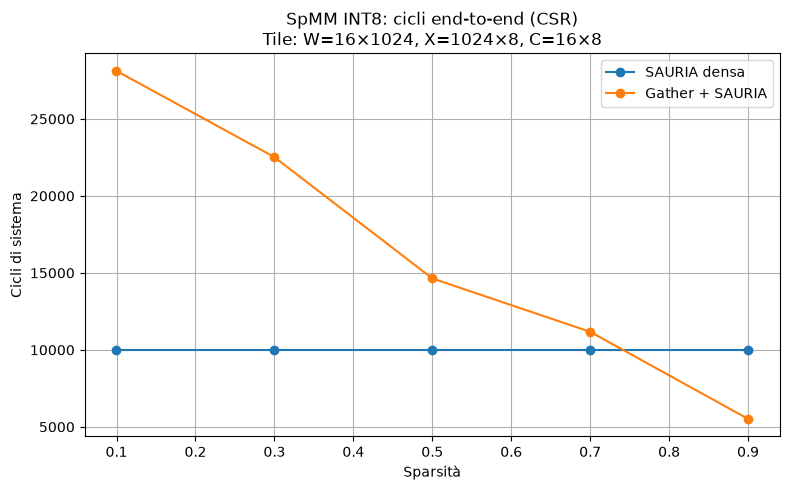

/home/henry/sauria/test/spmm_gather_vs_dense_int8_8x16_axi64/cycles_vs_sparsity_int8_csr.png


In [10]:
if not results.empty:
    figure = plt.figure(figsize=(8, 5))
    plt.plot(results["sparsity"], results["dense_cycles"], marker="o", label="SAURIA densa")
    plt.plot(
        results["sparsity"],
        results["gather_plus_sauria_cycles"],
        marker="o",
        label="Gather + SAURIA",
    )
    plt.xlabel("Sparsità")
    plt.ylabel("Cicli di sistema")
    plt.title(f"SpMM INT8: cicli end-to-end ({SPARSE_FORMAT})\nTile: W={M}×{K}, X={K}×{N}, C={M}×{N}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / f"cycles_vs_sparsity_int8_{SPARSE_FORMAT.lower()}.png"
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


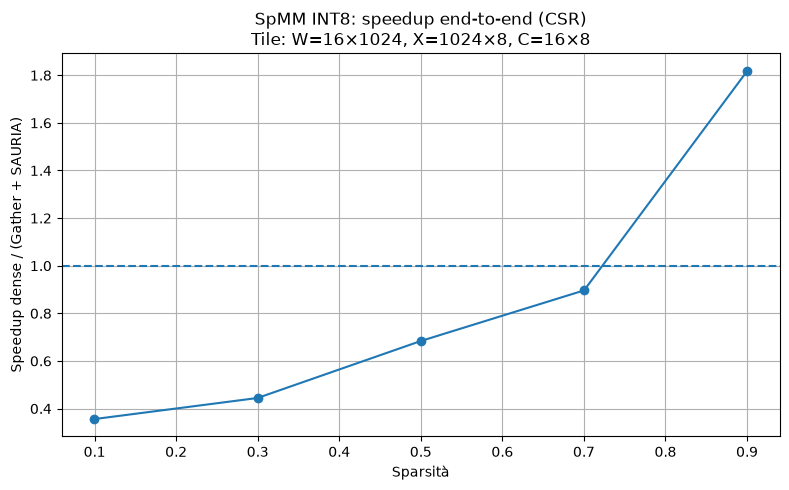

/home/henry/sauria/test/spmm_gather_vs_dense_int8_8x16_axi64/speedup_vs_sparsity_int8_csr.png


In [11]:
if not results.empty:
    figure = plt.figure(figsize=(8, 5))
    plt.plot(results["sparsity"], results["speedup_end_to_end"], marker="o")
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("Sparsità")
    plt.ylabel("Speedup dense / (Gather + SAURIA)")
    plt.title(f"SpMM INT8: speedup end-to-end ({SPARSE_FORMAT})\nTile: W={M}×{K}, X={K}×{N}, C={M}×{N}")
    plt.grid(True)
    plt.tight_layout()
    path = RESULTS_ROOT / f"speedup_vs_sparsity_int8_{SPARSE_FORMAT.lower()}.png"
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


## 10. Ispezione del punto più sparso

La cella mostra gli array CSR/CSC e il manifest Gather del punto più sparso
completato.


In [12]:
if not results.empty:
    case_root = Path(results.iloc[-1]["case_root"])
    arrays = np.load(case_root / "operands_and_sparse_formats.npz")

    print("Caso:", case_root)
    print("active_columns:", arrays["active_columns"])
    print("CSR row_ptr:", arrays["csr_row_ptr"])
    print("CSR col_idx, primi 32:", arrays["csr_col_idx"][:32])
    print("CSC col_ptr:", arrays["csc_col_ptr"])
    print("CSC row_idx, primi 32:", arrays["csc_row_idx"][:32])

    print("\nManifest Gather:")
    print((case_root / "gather_stimuli/manifest.json").read_text())


Caso: /home/henry/sauria/test/spmm_gather_vs_dense_int8_8x16_axi64/csr_K1024_keff102_s0.9004
active_columns: [   5   11   12   30   35   40   49   71   74   75   81   91   94  127
  135  148  149  158  159  189  194  197  209  228  239  250  272  280
  283  285  293  295  338  370  371  373  375  384  388  395  411  415
  421  435  444  445  447  450  456  457  469  472  482  485  489  500
  503  510  534  536  560  567  570  598  604  620  631  647  648  662
  663  664  703  720  765  777  778  802  822  826  833  835  840  841
  844  872  890  897  900  907  910  920  926  928  936  980  986  987
  990  991  995 1004]
CSR row_ptr: [   0  102  204  306  408  510  612  714  816  918 1020 1122 1224 1326
 1428 1530 1632]
CSR col_idx, primi 32: [  5  11  12  30  35  40  49  71  74  75  81  91  94 127 135 148 149 158
 159 189 194 197 209 228 239 250 272 280 283 285 293 295]
CSC col_ptr: [   0    0    0 ... 1632 1632 1632]
CSC row_idx, primi 32: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14

## Interpretazione e limiti

Il benchmark mantiene la stessa matrice logica `W[M,K]`, la stessa `X[K,N]`
e lo stesso risultato INT32.

La compressione a `k_eff` è valida con un singolo lancio perché tutte le
righe di W condividono le stesse colonne non nulle. Per una CSR/CSC
completamente irregolare servono più lanci o il raggruppamento delle righe
per pattern.

Prerequisiti RTL:

- file `RTL/hw_versions/int8_8x16_AXI64.svh`;
- voce `int8_8x16_AXI64` in `Python/src/hw_versions.py`;
- Gather con `.ByteWidth(sauria_pkg::IA_W)`;
- correzioni `skip_initial_A`, `PREPARE_B` e multi-burst già validate.